<a href="https://colab.research.google.com/github/DaeYejun2/PyTorch/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digit Recognizer - High-Resolution Network

In [60]:
# Hyperparameter
IS_TRAIN = True

BN_MOMENTUM = 0.1
NUM_EPOCHS = 2
BATCH_SIZE = 64
LEARNING_RATE = 0.01

In [47]:
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, Dataset, TensorDataset

In [48]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

## Read and prepare data

In [49]:
df = pd.read_csv('train.csv')

In [50]:
df.head(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


torch.Size([64, 1, 224, 224])
torch.Size([64])
1


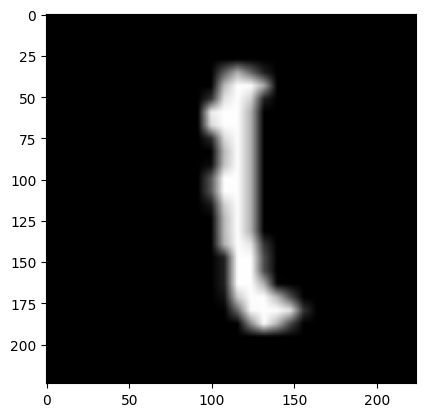

In [51]:
def split_data(df, test_size=0.2):
  X = df.iloc[:, 1:].values
  y = df.iloc[:, 0].values

  indices = np.random.permutation(len(X))
  split_index = int(len(X) * (1 - test_size))

  train_indices = indices[:split_index]
  val_indices = indices[split_index:]

  X_train = X[train_indices]
  y_train = y[train_indices]
  X_val = X[val_indices]
  y_val = y[val_indices]

  return X_train, y_train, X_val, y_val

class ResizedDigitDataset(Dataset):
  def __init__(self, X, y):
    self.X = X.reshape(-1, 28, 28).astype(np.uint8)  # Reshape 28x28
    self.y = y
    self.transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize( (0.1307,), (0.3081,))
    ])

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    image = self.X[idx]
    label = self.y[idx]
    image = self.transform(image)
    return image, label

X_train, y_train, X_val, y_val = split_data(df)
train_dataset = ResizedDigitDataset(X_train, y_train)
val_dataset = ResizedDigitDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

for data, target in train_loader:
  print(data.shape)
  print(target.shape)
  plt.imshow(data[0].reshape((224, 224)), cmap='gray')
  print(target[0].item())
  break

## Model definition

###### https://github.com/HRNet/HRNet-Image-Classification/blob/master/lib/models/cls_hrnet.py

In [52]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes, momentum=BN_MOMENTUM)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes, momentum=BN_MOMENTUM)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = self.relu(out)
        return out

In [53]:
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes, momentum=BN_MOMENTUM)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes, momentum=BN_MOMENTUM)
        self.conv3 = nn.Conv2d(planes, planes * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion, momentum=BN_MOMENTUM)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv3(out)
        out = self.bn3(out)
        out += identity
        out = self.relu(out)
        return out

In [54]:
class HighResolutionModule(nn.Module):
    def __init__(self, num_branches, block, num_blocks, num_inchannels, num_channels, fuse_method, multi_scale_output=True):
        super(HighResolutionModule, self).__init__()
        self.num_branches = num_branches
        self.num_inchannels = num_inchannels
        self.fuse_method = fuse_method
        self.multi_scale_output = multi_scale_output

        self.branches = self._make_branches(num_branches, block, num_blocks, num_channels)
        self.fuse_layers = self._make_fuse_layers()
        self.relu = nn.ReLU(False)

    def _make_one_branch(self, branch_index, block, num_blocks, num_channels, stride=1):
        downsample = None
        if stride != 1 or self.num_inchannels[branch_index] != num_channels[branch_index] * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.num_inchannels[branch_index], num_channels[branch_index] * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(num_channels[branch_index] * block.expansion, momentum=BN_MOMENTUM),
            )
        layers = [block(self.num_inchannels[branch_index], num_channels[branch_index], stride, downsample)]
        self.num_inchannels[branch_index] = num_channels[branch_index] * block.expansion
        for _ in range(1, num_blocks[branch_index]):
            layers.append(block(self.num_inchannels[branch_index], num_channels[branch_index]))
        return nn.Sequential(*layers)

    def _make_branches(self, num_branches, block, num_blocks, num_channels):
        return nn.ModuleList([self._make_one_branch(i, block, num_blocks, num_channels) for i in range(num_branches)])

    def _make_fuse_layers(self):
        if self.num_branches == 1:
            return None
        num_inchannels = self.num_inchannels
        fuse_layers = []
        for i in range(self.num_branches):
            fuse_layer = []
            for j in range(self.num_branches):
                if j > i:
                    fuse_layer.append(nn.Sequential(
                        nn.Conv2d(num_inchannels[j], num_inchannels[i], 1, 1, 0, bias=False),
                        nn.BatchNorm2d(num_inchannels[i], momentum=BN_MOMENTUM),
                        nn.Upsample(scale_factor=2 ** (j - i), mode='nearest')))
                elif j == i:
                    fuse_layer.append(None)
                else:
                    conv3x3s = []
                    for k in range(i - j):
                        num_outchannels_conv3x3 = num_inchannels[i] if k == i - j - 1 else num_inchannels[j]
                        conv3x3s.append(nn.Sequential(
                            nn.Conv2d(num_inchannels[j], num_outchannels_conv3x3, 3, 2, 1, bias=False),
                            nn.BatchNorm2d(num_outchannels_conv3x3, momentum=BN_MOMENTUM),
                            nn.ReLU(False)))
                    fuse_layer.append(nn.Sequential(*conv3x3s))
            fuse_layers.append(nn.ModuleList(fuse_layer))
        return nn.ModuleList(fuse_layers)

    def forward(self, x):
        if self.num_branches == 1:
            return [self.branches[0](x[0])]
        for i in range(self.num_branches):
            x[i] = self.branches[i](x[i])
        x_fuse = []
        for i in range(len(self.fuse_layers)):
            y = x[0] if i == 0 else self.fuse_layers[i][0](x[0])
            for j in range(1, self.num_branches):
                y = y + (x[j] if i == j else self.fuse_layers[i][j](x[j]))
            x_fuse.append(self.relu(y))
        return x_fuse

    def get_num_inchannels(self):
        return self.num_inchannels

In [55]:
class HighResolutionNet(nn.Module):
    def __init__(self):
        super(HighResolutionNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=2, padding=1, bias=False)  # Change input channels to 1 for MNIST
        self.bn1 = nn.BatchNorm2d(64, momentum=BN_MOMENTUM)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(64, momentum=BN_MOMENTUM)
        self.relu = nn.ReLU(inplace=True)

        # Stage 1
        self.layer1 = self._make_layer(Bottleneck, 64, 64, 4)
        stage1_out_channel = Bottleneck.expansion * 64

        # Stage 2
        num_channels = [18, 36]
        block = BasicBlock
        num_channels = [nc * block.expansion for nc in num_channels]
        self.transition1 = self._make_transition_layer([stage1_out_channel], num_channels)
        self.stage2, pre_stage_channels = self._make_stage(2, block, [4, 4], num_channels)

        # Stage 3
        num_channels = [18, 36, 72]
        block = BasicBlock
        num_channels = [nc * block.expansion for nc in num_channels]
        self.transition2 = self._make_transition_layer(pre_stage_channels, num_channels)
        self.stage3, pre_stage_channels = self._make_stage(3, block, [4, 4, 4], num_channels)

        # Stage 4
        num_channels = [18, 36, 72, 144]
        block = BasicBlock
        num_channels = [nc * block.expansion for nc in num_channels]
        self.transition3 = self._make_transition_layer(pre_stage_channels, num_channels)
        self.stage4, pre_stage_channels = self._make_stage(4, block, [4, 4, 4, 4], num_channels)

        self.incre_modules, self.downsamp_modules, self.final_layer = self._make_head(pre_stage_channels)

        self.classifier = nn.Linear(2048, 10)

    def _make_transition_layer(self, num_channels_pre_layer, num_channels_cur_layer):
        transition_layers = []
        for i in range(len(num_channels_cur_layer)):
            if i < len(num_channels_pre_layer):
                if num_channels_cur_layer[i] != num_channels_pre_layer[i]:
                    transition_layers.append(nn.Sequential(
                        nn.Conv2d(num_channels_pre_layer[i], num_channels_cur_layer[i], 3, 1, 1, bias=False),
                        nn.BatchNorm2d(num_channels_cur_layer[i], momentum=BN_MOMENTUM),
                        nn.ReLU(inplace=True)))
                else:
                    transition_layers.append(None)
            else:
                conv3x3s = []
                for j in range(i + 1 - len(num_channels_pre_layer)):
                    in_channels = num_channels_pre_layer[-1]
                    out_channels = num_channels_cur_layer[i] if j == i - len(num_channels_pre_layer) else in_channels
                    conv3x3s.append(nn.Sequential(
                        nn.Conv2d(in_channels, out_channels, 3, 2, 1, bias=False),
                        nn.BatchNorm2d(out_channels, momentum=BN_MOMENTUM),
                        nn.ReLU(inplace=True)))
                transition_layers.append(nn.Sequential(*conv3x3s))
        return nn.ModuleList(transition_layers)

    def _make_layer(self, block, inplanes, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(inplanes, planes * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion, momentum=BN_MOMENTUM),
            )
        layers = [block(inplanes, planes, stride, downsample)]
        inplanes = planes * block.expansion
        layers.extend(block(inplanes, planes) for _ in range(1, blocks))
        return nn.Sequential(*layers)

    def _make_stage(self, num_branches, block, num_blocks, num_channels, multi_scale_output=True):
        num_modules = num_branches
        num_inchannels = num_channels
        modules = nn.ModuleList()
        for i in range(num_modules):
            reset_multi_scale_output = multi_scale_output if i < num_modules - 1 else False
            modules.append(HighResolutionModule(num_branches, block, num_blocks, num_inchannels, num_channels, 'SUM', reset_multi_scale_output))
            num_inchannels = modules[-1].get_num_inchannels()
        return nn.Sequential(*modules), num_inchannels

    def _make_head(self, pre_stage_channels):
        head_block = Bottleneck
        head_channels = [32, 64, 128, 256]

        incre_modules = nn.ModuleList([self._make_layer(head_block, ch, hc, 1, stride=1)
                                       for ch, hc in zip(pre_stage_channels, head_channels)])

        downsamp_modules = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(hc * head_block.expansion, hc_next * head_block.expansion, 3, 2, 1, bias=False),
                nn.BatchNorm2d(hc_next * head_block.expansion, momentum=BN_MOMENTUM),
                nn.ReLU(inplace=True)
            ) for hc, hc_next in zip(head_channels[:-1], head_channels[1:])
        ])

        final_layer = nn.Sequential(
            nn.Conv2d(head_channels[-1] * head_block.expansion, 2048, 1, 1, 0),
            nn.BatchNorm2d(2048, momentum=BN_MOMENTUM),
            nn.ReLU(inplace=True)
        )

        return incre_modules, downsamp_modules, final_layer

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.layer1(x)

        x_list = [self.transition1[i](x) if self.transition1[i] is not None else x for i in range(2)]
        y_list = self.stage2(x_list)

        x_list = [self.transition2[i](y_list[-1]) if self.transition2[i] is not None else y_list[i] for i in range(3)]
        y_list = self.stage3(x_list)

        x_list = [self.transition3[i](y_list[-1]) if self.transition3[i] is not None else y_list[i] for i in range(4)]
        y_list = self.stage4(x_list)

        y = self.incre_modules[0](y_list[0])
        for i in range(len(self.downsamp_modules)):
            y = self.incre_modules[i + 1](y_list[i + 1]) + self.downsamp_modules[i](y)
        y = self.final_layer(y)

        if torch._C._get_tracing_state():
            y = y.flatten(start_dim=2).mean(dim=2)
        else:
            y = F.avg_pool2d(y, kernel_size=y.size()[2:]).view(y.size(0), -1)
        y = self.classifier(y)
        return y

### Model training

In [56]:
def train(model, device, train_loader, optimizer, criterion):
  model.train()
  train_loss = 0.0
  correct_train = 0

  for data, target in train_loader:
    data, target = data.to(device), target.to(device)
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output, target)
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
    pred_train = output.argmax(dim=1, keepdim=True)
    correct_train += pred_train.eq(target.view_as(pred_train)).sum().item()

  train_loss /= len(train_loader)
  train_accurancy = 100. * correct_train / len(train_loader.dataset)

  return train_loss, train_accurancy

In [57]:
def evaluate(model, device, test_loader, criterion):
  model.eval()
  test_loss = 0.0
  correct_test = 0

  with torch.no_grad():
    for data, target in test_loader:
      data, target = data.to(device), target.to(device)
      output = model(data)
      test_loss += criterion(output, target).item()
      pred_test = output.argmax(dim=1, keepdim=True)
      correct_test += pred_test.eq(target.view_as(pred_test)).sum().item()

  test_loss /= len(test_loader.dataset)
  test_accurancy = 100. * correct_test / len(test_loader.dataset)

  return test_loss, test_accurancy

In [58]:
model = HighResolutionNet().to(device)

optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)
criterion = nn.CrossEntropyLoss()

In [61]:
if IS_TRAIN:
  train_losses = []
  val_losses = []
  train_accuracies = []
  val_accuracies = []
  best_accuracy = 0.0
  best_model = None

  for epoch in range(NUM_EPOCHS):
    print(f'Start training epoch: {epoch + 1}/{NUM_EPOCHS}')

    epoch_train_loss, train_accuracy = train(model, device, train_loader, optimizer, criterion)

    train_losses.append(epoch_train_loss)
    train_accuracies.append(train_accuracy)

    val_loss, val_accuracy = evaluate(model, device, val_loader, criterion)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    if val_accuracy > best_accuracy:
      best_accuracy = val_accuracy
      best_model = model.state_dict()

    print(f'Epoch {epoch + 1}, Train Loss: {epoch_train_loss:.4f}, val Loss: {val_loss:.4f}, '
            f'Train Accuracy: {train_accuracy:.2f}%, val Accuracy: {val_accuracy:.2f}%')
  torch.save(best_model, 'best_model.pth')


Start training epoch: 1/2
Epoch 1, Train Loss: 0.1188, val Loss: 0.0014, Train Accuracy: 96.40%, val Accuracy: 97.35%
Start training epoch: 2/2
Epoch 2, Train Loss: 0.0417, val Loss: 0.0006, Train Accuracy: 98.71%, val Accuracy: 98.70%


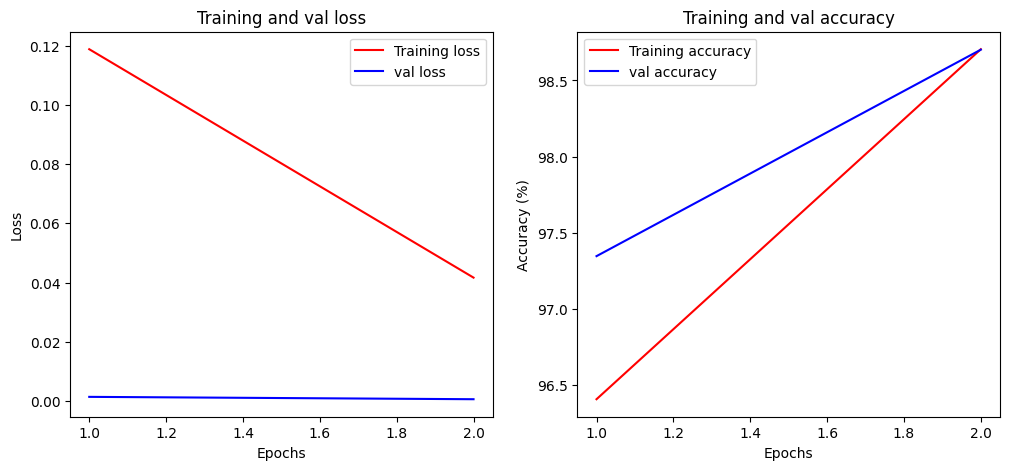

Best model saved with accuracy: 98.70%


In [62]:
if IS_TRAIN:
    # Plotting the results
    epochs = range(1, NUM_EPOCHS + 1)
    plt.figure(figsize=(12, 5))

    # Plot train and val loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'r', label='Training loss')
    plt.plot(epochs, val_losses, 'b', label='val loss')
    plt.title('Training and val loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot train and val accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'r', label='Training accuracy')
    plt.plot(epochs, val_accuracies, 'b', label='val accuracy')
    plt.title('Training and val accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.show()

    # Save the best model
    torch.save(best_model, 'best_model.pth')
    print(f'Best model saved with accuracy: {best_accuracy:.2f}%')

In [63]:
if IS_TRAIN:
    model = HighResolutionNet().to(device)
    model.load_state_dict(torch.load('best_model.pth', map_location=device))
    model.eval()
else:
    model = HighResolutionNet().to(device)
    model.load_state_dict(torch.load('/kaggle/input/hrnet-model/pytorch/default/1/best_model.pth', map_location=device))
    model.eval()


# Đánh giá mô hình đã lưu trên tập val
val_loss, val_accuracy = evaluate(model, device, val_loader, criterion)
print(f'val Loss: {val_loss:.4f}, val Accuracy: {val_accuracy:.2f}%')

val Loss: 0.0006, val Accuracy: 98.70%


In [64]:
def predict(model, data_loader):
    model.eval()
    all_predictions = []

    with torch.no_grad():
        for data, _ in data_loader:
            outputs = model(data)  # Dự đoán
            _, predicted = torch.max(outputs, 1)
            all_predictions.append(predicted)

    return torch.cat(all_predictions)

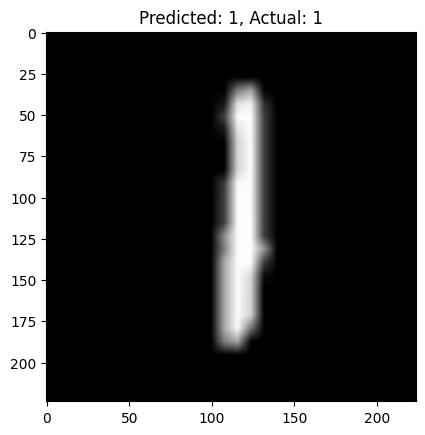

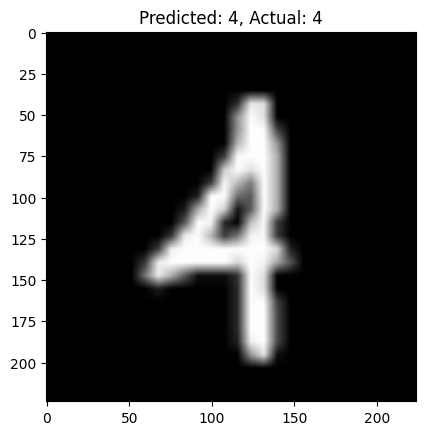

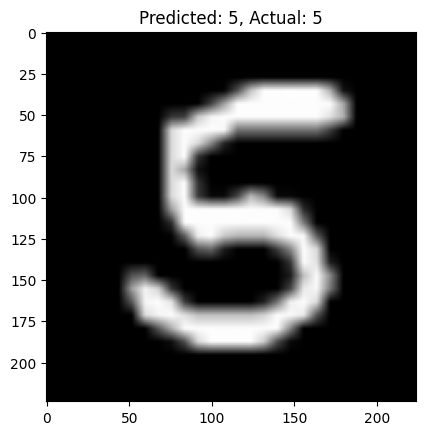

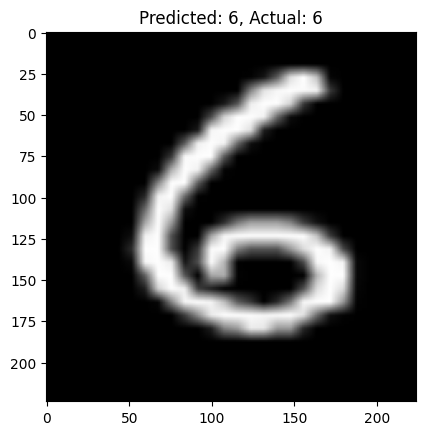

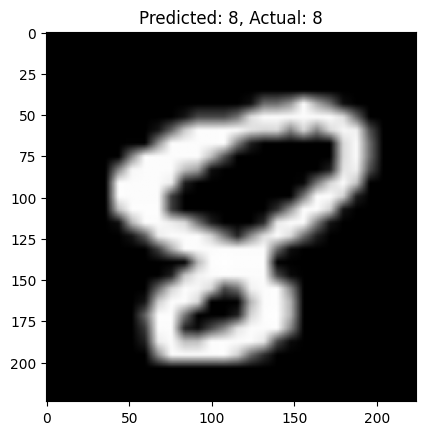

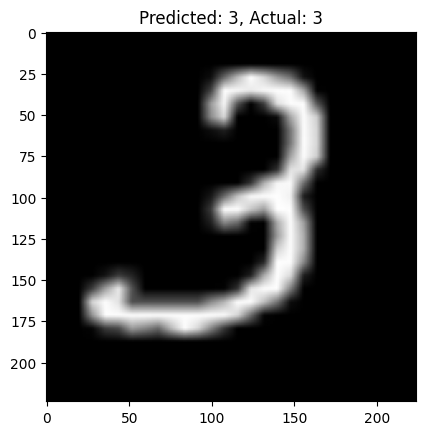

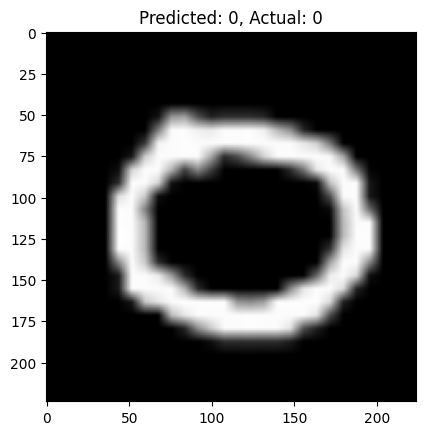

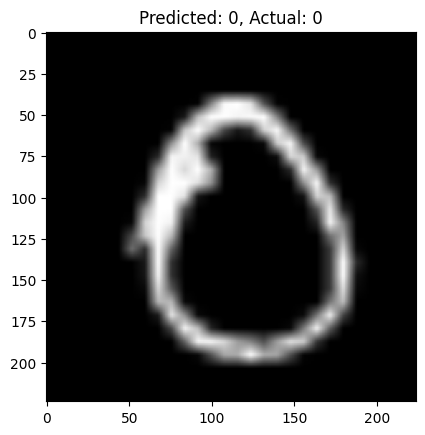

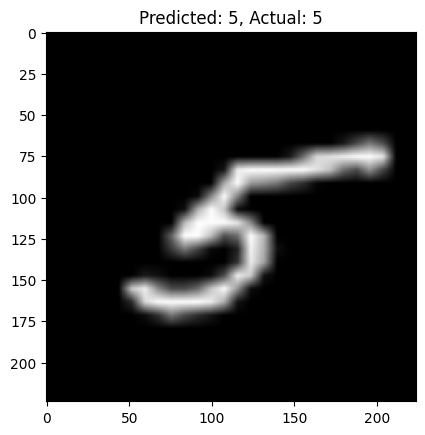

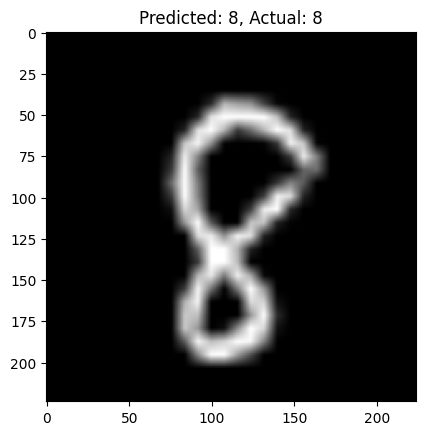

In [65]:
indices = random.sample(range(len(val_dataset)), 10)
samples = torch.utils.data.Subset(val_dataset, indices)
sample_loader = DataLoader(samples, batch_size=BATCH_SIZE, shuffle=False)

# Dự đoán và in kết quả
with torch.no_grad():
    for data, target in sample_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        pred = output.argmax(dim=1, keepdim=True)

        # In ra kết quả dự đoán
        for i in range(len(data)):
            plt.imshow(data[i].cpu().numpy().transpose(1, 2, 0), cmap='gray')
            plt.title(f'Predicted: {pred[i].item()}, Actual: {target[i].item()}')
            plt.show()